In [1]:
import os
import glob

import numpy as np
import xarray as xr

import csv
import pop_tools
import gsw

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cmocean.cm as cmo
import cartopy
import matplotlib.ticker as ticker
from matplotlib import animation, gridspec
from matplotlib.gridspec import GridSpec

ccrs = cartopy.crs

nature_coast = cartopy.feature.NaturalEarthFeature('physical', 'land', '50m',linewidth=0.5, edgecolor='black', facecolor='whitesmoke')

# time series and maps

In [2]:
ds_temp = xr.open_dataset('/Data/skd/scratch/innag3580/comp/composites/Below_combined_TEMP_3.0_40_20.nc').roll(nlon=+100)
ds_salt = xr.open_dataset('/Data/skd/scratch/innag3580/comp/composites/Below_combined_SALT_3.0_40_20.nc').roll(nlon=+100)
ds_hmxl = xr.open_dataset('/Data/skd/scratch/innag3580/comp/composites/Below_combined_HMXL_3.0_40_20.nc').roll(nlon=+100)
ds_shf  = xr.open_dataset('/Data/skd/scratch/innag3580/comp/composites/Below_combined_SHF_3.0_40_20.nc').roll(nlon=+100)
ds_n_heat  = xr.open_dataset('/Data/skd/scratch/innag3580/comp/composites/Below_combined_N_HEAT_3.0_40_20_ghg_hist.nc')
ds_hmxl['HMXL']=ds_hmxl.HMXL*1e-2

In [44]:
path = '/Data/skd/scratch/innag3580/comp/composites/'
ds_smoc = xr.open_dataset(os.path.join(path, f'Below_combined_smoc_3.0_40_20_ghg_hist.nc'))
ds_dmoc = xr.open_dataset(os.path.join(path, f'Below_combined_dmoc_3.0_40_20_ghg_hist.nc'))
ds_bsf  = xr.open_dataset(os.path.join(path, f'Below_combined_bsf_3.0_40_20_ghg_hist.nc')).roll(nlon=+100)

In [4]:
CT = gsw.conversions.CT_from_pt(ds_salt['SALT'], ds_temp['TEMP'])
sigma2 = gsw.density.sigma2(ds_salt['SALT'], CT)
sigma2 = xr.DataArray(sigma2, name='DENS2', dims=ds_temp['TEMP'].dims, coords=ds_temp['TEMP'].coords)

ds_dens = ds_temp
ds_dens = ds_dens.drop_vars('TEMP')
ds_dens['DENS2'] = sigma2

In [5]:
ds_bsf = ds_bsf.assign_coords(TLAT=ds_temp.TLAT)
ds_bsf = ds_bsf.assign_coords(TLAT=ds_temp.TLONG)

In [6]:
grid_name = 'POP_gx1v7'
region_defs = {
    'SubpolarAtlantic':[
        {'match': {'REGION_MASK': [6]}, 'bounds': {'TLAT': [10.0, 80.0], 'TLONG': [260.0, 360.0]}}   
    ],
    'LabradorSea': [
        {'match': {'REGION_MASK': [8]}}]}
NA_mask = pop_tools.region_mask_3d(grid_name, region_defs=region_defs, mask_name='North Atlantic')
NA_mask = NA_mask.sum('region')

grid_name = 'POP_gx1v7'
region_defs = {
    'SubpolarAtlantic': [
        {'match': {'REGION_MASK': [6]}, 'bounds': {'TLAT': [50.0, 65.0], 'TLONG': [200.0, 360.0]}}
    ],
    'LabradorSea': [
        {'match': {'REGION_MASK': [8]}, 'bounds': {'TLAT': [50.0, 65.0], 'TLONG': [260.0, 360.0]}}]}
SPNA_mask = pop_tools.region_mask_3d(grid_name, region_defs=region_defs, mask_name='North Atlantic')
SPNA_mask = SPNA_mask.sum('region')

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Timeseries

In [14]:
ds_heat = ds_temp.where(SPNA_mask == 1)
ds_fresh = ds_salt.where(SPNA_mask == 1)

In [15]:
# Define physical constants
rho_sw = 1026  # density of seawater in kg/m^3
cp_sw = 3990  # specific heat of seawater in J/(kg·K)

# Convert units to meters and square meters
ds_heat['dz'] = ds_heat.dz * 1e-2
ds_heat['UAREA'] = ds_heat.UAREA * 1e-4

# Define reference salinity
S_ref = 35  # PSU

# Convert units to meters and square meters
ds_fresh['dz'] = ds_fresh.dz * 1e-2
ds_fresh['UAREA'] = ds_fresh.UAREA * 1e-4

In [16]:
# Compute heat content
heat_content = rho_sw * cp_sw * (ds_heat.dz * ds_heat.TAREA * ds_heat.TEMP).sum(dim=['nlat', 'nlon', 'z_t'])

# Freshwater content computation (add this line)
freshwater_content = ((S_ref - ds_fresh.SALT) / S_ref * ds_fresh.dz * ds_fresh.UAREA).sum(dim=['nlat', 'nlon', 'z_t'])

In [23]:
smoc_55 = (ds_smoc.sMOC.isel(nlat=340).max('dens2')*1e-12)
dmoc_26 = (ds_dmoc.dMOC.isel(nlat=280).max('z_t')*1e-12)
bsf_spna = (ds_bsf.BSF.where(SPNA_mask == 1).min(dim=['nlat', 'nlon'])*1e-12)

In [24]:
# SPNA density 
ds_spna_dens = ds_dens.where(SPNA_mask == 1)
weights = ds_spna_dens.z_t * ds_spna_dens.TAREA
weights = weights.fillna(0)
spna_dens = ds_spna_dens.DENS2.weighted(weights).sum(dim=['nlat', 'nlon', 'z_t'])

# SPNA hmxl
ds_spna_hmxl = ds_hmxl.where(SPNA_mask == 1)
weights = ds_spna_hmxl.TAREA
weights = weights.fillna(0)
spna_hmxl = ds_hmxl.HMXL.weighted(weights).sum(dim=['nlat', 'nlon'])

# SPNA hmxl
ds_spna_shf = ds_shf.where(SPNA_mask == 1)
weights = ds_spna_shf.TAREA
weights = weights.fillna(0)
spna_shf = ds_shf.SHF.weighted(weights).sum(dim=['nlat', 'nlon'])

In [25]:
n_heat_45 = ds_n_heat.N_HEAT.isel(transport_reg=1, transport_comp=1).sel(lat_aux_grid=47.432735)

In [26]:
def normalise_time_series(timeseries):
    mean_initial = timeseries.isel(time=slice(0, 40)).mean('time')
    std_initial = timeseries.isel(time=slice(0, 40)).std('time')
    delta_timeseries = (timeseries - mean_initial) / std_initial
    #delta_timeseries = (timeseries - mean_initial) / mean_initial
    return delta_timeseries

In [27]:
delta_heat_content = normalise_time_series(heat_content)
delta_freshwater_content = normalise_time_series(freshwater_content)
delta_spna_dens = normalise_time_series(spna_dens)

delta_spna_hmxl = normalise_time_series(spna_hmxl)
delta_spna_shf = normalise_time_series(spna_shf)
delta_n_heat_45 = normalise_time_series(n_heat_45)

delta_smoc_55 = normalise_time_series(smoc_55)
delta_dmoc_26 = normalise_time_series(dmoc_26)
delta_bsf_spna = normalise_time_series(bsf_spna)

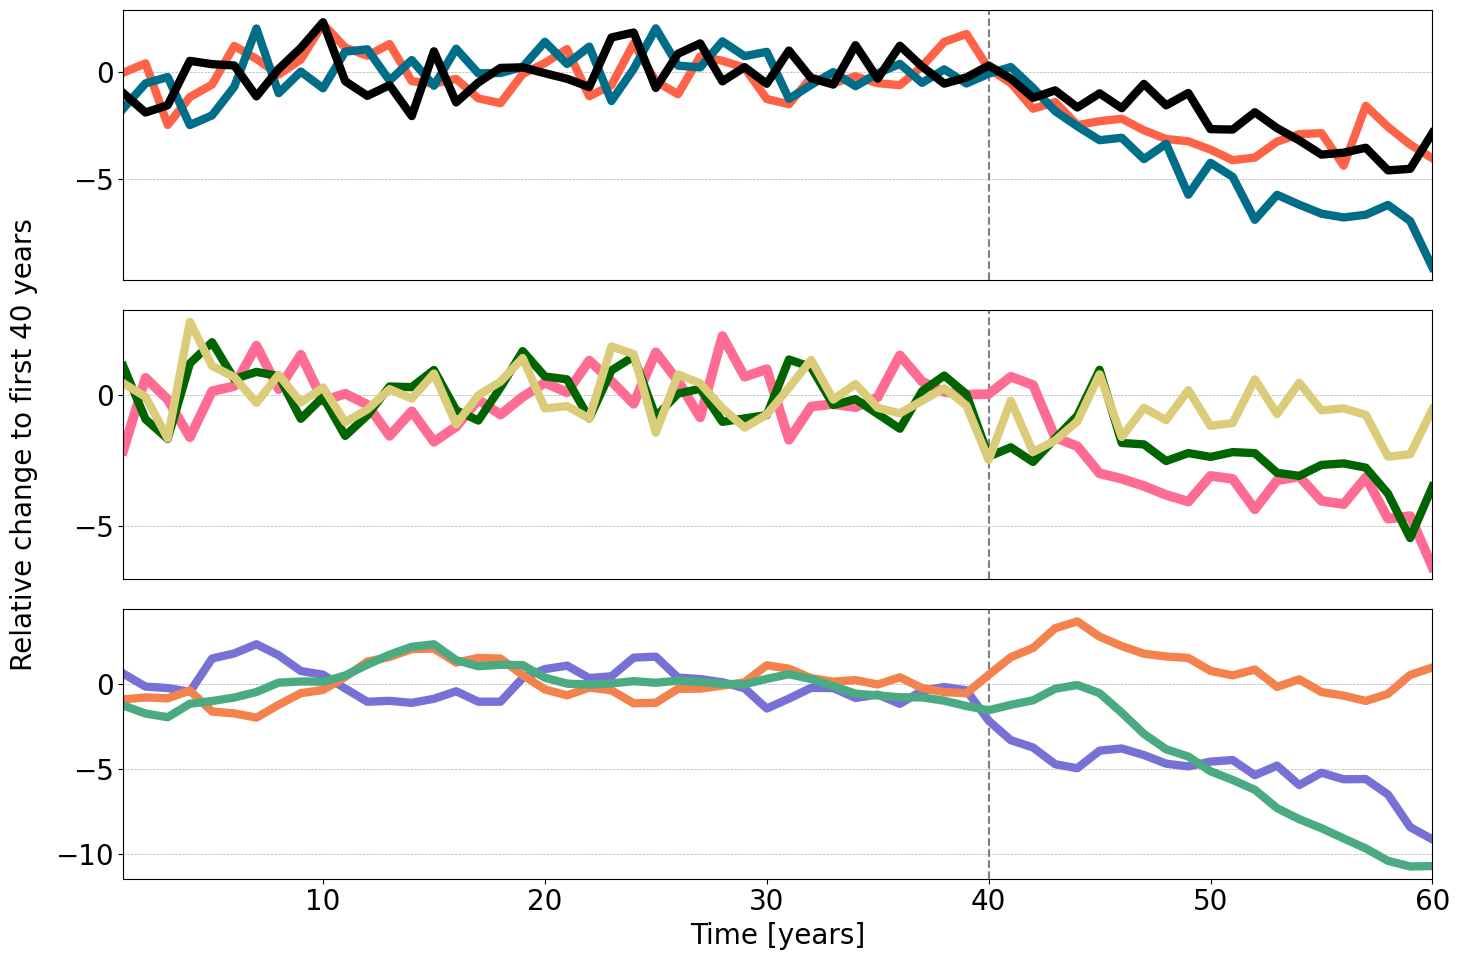

In [30]:

colors = {
    'heat_content': cmo.thermal(0.7),  
    'freshwater_content': cmo.haline(0.6),  
    'spna_dens': cmo.dense(0.5),  
    'spna_hmxl': '#006400',  
    'spna_shf': '#DBCC79',
    'n_heat_45': '#FF6347',
    'smoc_55': '#016E89',
    'bsf_spna': '#FF6C93',
    'dmoc26': 'k'
}

labelsize = 20

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 10))
plt.rc('font', size=20)

axes[0].axvline(x=40, color='grey', linestyle='--')
axes[0].plot(delta_n_heat_45.time + 1, delta_n_heat_45, linewidth=6, color=colors['n_heat_45'], label='Heat transport at 45°')
axes[0].plot(delta_smoc_55.time + 1, delta_smoc_55, linewidth=6, color=colors['smoc_55'], label=r'max $\Psi_{\sigma}$ at 55°N')
#axes[0].plot(delta_bsf_spna.time + 1, -delta_bsf_spna, linewidth=6, color=colors['bsf_spna'], label=r'max $\Psi_{bt}$ in SPG')
axes[0].plot(delta_dmoc_26.time + 1, delta_dmoc_26, linewidth=6, color=colors['dmoc26'], label=r'max $\Psi_{d}$ at 26°N')
axes[0].set_xlim(1, 60)
axes[0].yaxis.grid(True, which='both', linestyle='--', linewidth=0.5)
axes[0].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

axes[1].axvline(x=40, color='grey', linestyle='--')
axes[1].plot(delta_bsf_spna.time + 1, -delta_bsf_spna, linewidth=7, color=colors['bsf_spna'], label=r'max $\Psi_{bt}$ in SPG')#
axes[1].plot(delta_spna_hmxl.time + 1, delta_spna_hmxl, linewidth=6, color=colors['spna_hmxl'], label='Mixed Layer Depth')
axes[1].plot(delta_spna_shf.time + 1, -delta_spna_shf, linewidth=6, color=colors['spna_shf'], label='Surface Heat Flux')
#axes[1].plot(delta_n_heat_45.time + 1, delta_n_heat_45, linewidth=6, color=colors['n_heat_45'], label='Heat transport at 45°')
axes[1].set_xlim(1, 60)
axes[1].yaxis.grid(True, which='both', linestyle='--', linewidth=0.5)
axes[1].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

axes[2].axvline(x=40, color='grey', linestyle='--')
axes[2].plot(delta_spna_dens.time + 1, delta_spna_dens, linewidth=6, color=colors['spna_dens'], label='Density')
axes[2].plot(delta_heat_content.time + 1, delta_heat_content, linewidth=6, color=colors['heat_content'], label='Heat Content')
axes[2].plot(delta_freshwater_content.time + 1, -delta_freshwater_content, linewidth=6, color=colors['freshwater_content'], label='Freshwater Content')
axes[2].set_xlabel('Time [years]')
axes[2].set_xlim(1, 60)
axes[2].yaxis.grid(True, which='both', linestyle='--', linewidth=0.5)

axes[1].set_ylabel('Relative change to first 40 years', fontsize=labelsize, labelpad=25)

plt.subplots_adjust(hspace=0.4)
plt.tight_layout()
#plt.show()
plt.savefig('Figure_Decrease_GHG_timeseries.png', bbox_inches='tight', dpi=300, transparent=True)

# Maps

In [45]:
datasets = {
    'TEMP': ds_temp,
    'SALT': ds_salt,
    'DENS2': ds_dens,
    'HMXL': ds_hmxl,
    'SHF': ds_shf,
    #'BSF': ds_bsf
}

# Define the replacement value
replacement_value = 0
# Iterate over the list of datasets and replace NaN, inf, and masked values
for ds in datasets.values():
    ds['TLAT'] = xr.where(
        np.logical_or(np.isnan(ds['TLAT']), np.isinf(ds['TLAT']) | np.ma.getmask(ds['TLAT'])),
        replacement_value,
        ds['TLAT']
    )
    ds['TLONG'] = xr.where(
        np.logical_or(np.isnan(ds['TLONG']), np.isinf(ds['TLONG']) | np.ma.getmask(ds['TLONG'])),
        replacement_value,
        ds['TLONG']
    )
    
datasets['BSF'] = ds_bsf

## TEMP, SALT, DENS2

In [8]:
variables = ['TEMP', 'SALT', 'DENS2']
labels = [r'Upper 500 meters' + '\n' + r'Temperature $\Delta$T [$^{\circ}$C]', 
          r'Upper 500 meters' + '\n' + r'Salinity $\Delta$S [$\frac{g}{kg}$]', 
          r'Upper 500 meters' + '\n' + r'Density $\Delta \sigma_2$ [$\frac{W}{m^2}$]']
cmaps = [cmo.balance, cmo.tarn_r, cmo.curl_r]
vmins = [-0.8, -0.3, -0.3]
years_ranges = [(25, 35), (35, 45), (45, 55)]
column_names = ['Pre-Shift (25-35 years)', 'Shift (35-45 years)', 'Post-Shift (45-55 years)']

save_name = 'Figure_Decrease_GHG_Flipbooks_Hydro.png'

KeyError: "'z_t' is not a valid dimension or coordinate"

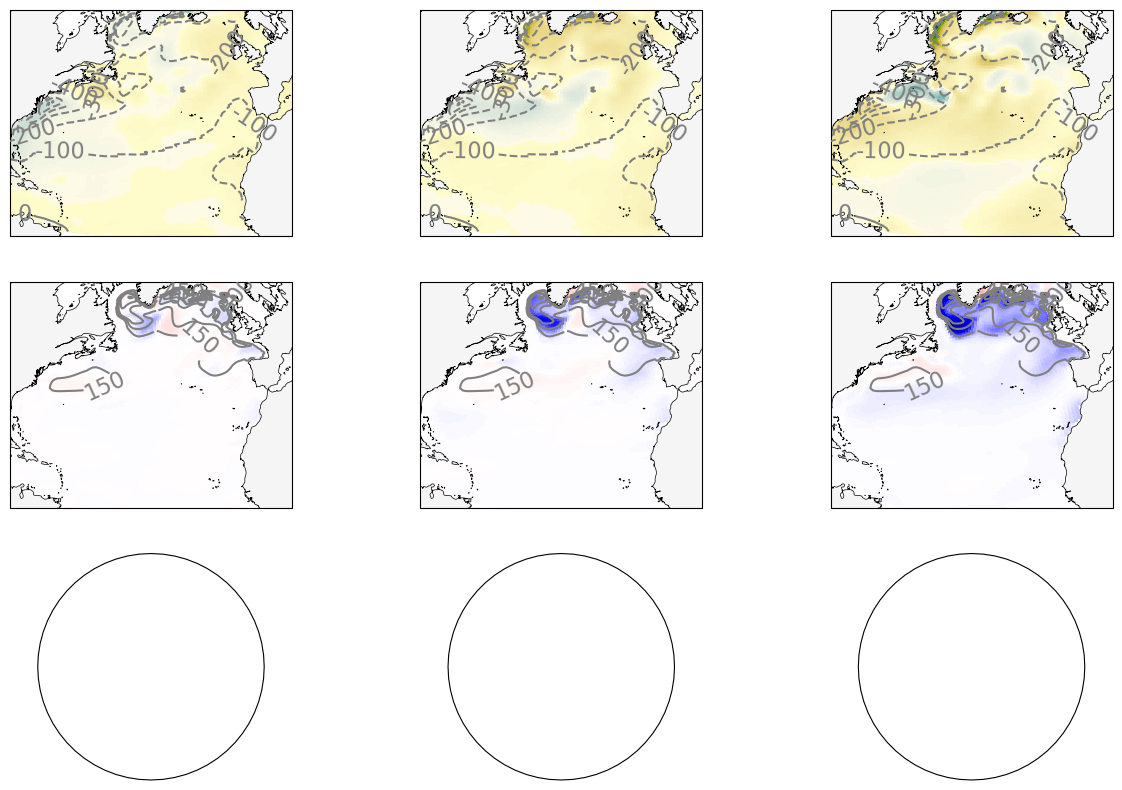

In [38]:
fontsize = 16

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10), 
                         subplot_kw={'projection': ccrs.Orthographic(central_latitude=20, central_longitude=-35)})
plt.rc('font', size=18)

for col, col_name in enumerate(column_names):
    axes[0, col].set_title(col_name, fontsize=20, pad=20)

for row, var in enumerate(variables):
    ds_var_annual = datasets[var].sel(z_t=slice(0, 500)).mean('z_t')
    ds = ds_var_annual - ds_var_annual.isel(time=slice(0, 40)).mean('time')
    vmin = vmins[row]
    vmax = -vmin
    for col, (start, end) in enumerate(years_ranges):
        ax = axes[row, col]
        da = ds.isel(time=slice(start, end)).mean('time')[var]
        pc = da.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(),
                                x='TLONG', y='TLAT',
            cmap=cmaps[row], vmin=vmin, vmax=vmax, add_colorbar=False)
        ax.set_extent([-75, -5, 10, 65], crs=ccrs.PlateCarree())
        ax.add_feature(nature_coast)

        #cs = ax.contour(ds.TLONG.where(NA_mask==1), ds.TLAT.where(NA_mask==1),
        #                ds_var_annual.isel(time=slice(0, 40)).mean('time')[var].where(NA_mask==1), 
        #                levels = np.linspace(vmin, vmax, 15),
        #                linewidths=1.5, colors='#4d4d4d', transform=ccrs.PlateCarree())
        
        cs = ax.contour(ds.TLONG, ds.TLAT, 
                        ds_var_annual.isel(time=slice(0, 40)).mean('time')[var].where(NA_mask == 1),
                        linewidths=1.5, colors='gray', transform=ccrs.PlateCarree())
        ax.clabel(cs, fmt='%1.0f', inline=True, fontsize=fontsize)
        ax.set_xlabel('') 
        ax.set_ylabel('') 

cbar_axes = [fig.add_axes([0.91, 0.67 - i * 0.27, 0.01, 0.2]) for i in range(3)]
for row in range(3):
    norm = plt.Normalize(vmin=vmins[row], vmax=-vmins[row])
    sm = plt.cm.ScalarMappable(cmap=cmaps[row], norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_axes[row])
    cbar.ax.set_ylabel('', fontsize=16)
for i, label in enumerate(labels):
    fig.text(0.991, 0.77 - i * 0.275, label, fontsize=fontsize, verticalalignment='center', horizontalalignment='center', rotation=90)
for col, name in enumerate(column_names):
    axes[0, col].set_title(name, fontsize=fontsize, pad=20)
    
plt.subplots_adjust(wspace=0.01, hspace=0.1)
plt.savefig(save_name, bbox_inches='tight', dpi=300)

plt.show()

## HMXL, SHF, BSF

In [46]:
# Sample data and variable settings
variables = ['SHF', 'HMXL', 'BSF']
labels = [r'Surface Heat Flux' + '\n' + r'$\Delta\Phi$ [$\frac{W}{m^2}$]',
          r'Mixed Layer Depth' + '\n' + r'$\Delta h$ [$m$]',
          r'Horizontal Transport' + '\n' + r'$\Delta BSF$ [$Sv$]']
cmaps = [cmo.delta, 'seismic', cmo.balance]
vmins = [-100, -180, -6]
years_ranges = [(25, 35), (35, 45), (45, 55)]
column_names = ['Pre-Shift (25-35 years)', 'Shift (35-45 years)', 'Post-Shift (45-55 years)']

save_name = 'Figure_Decrease_GHG_Flipbooks_Circu.png'

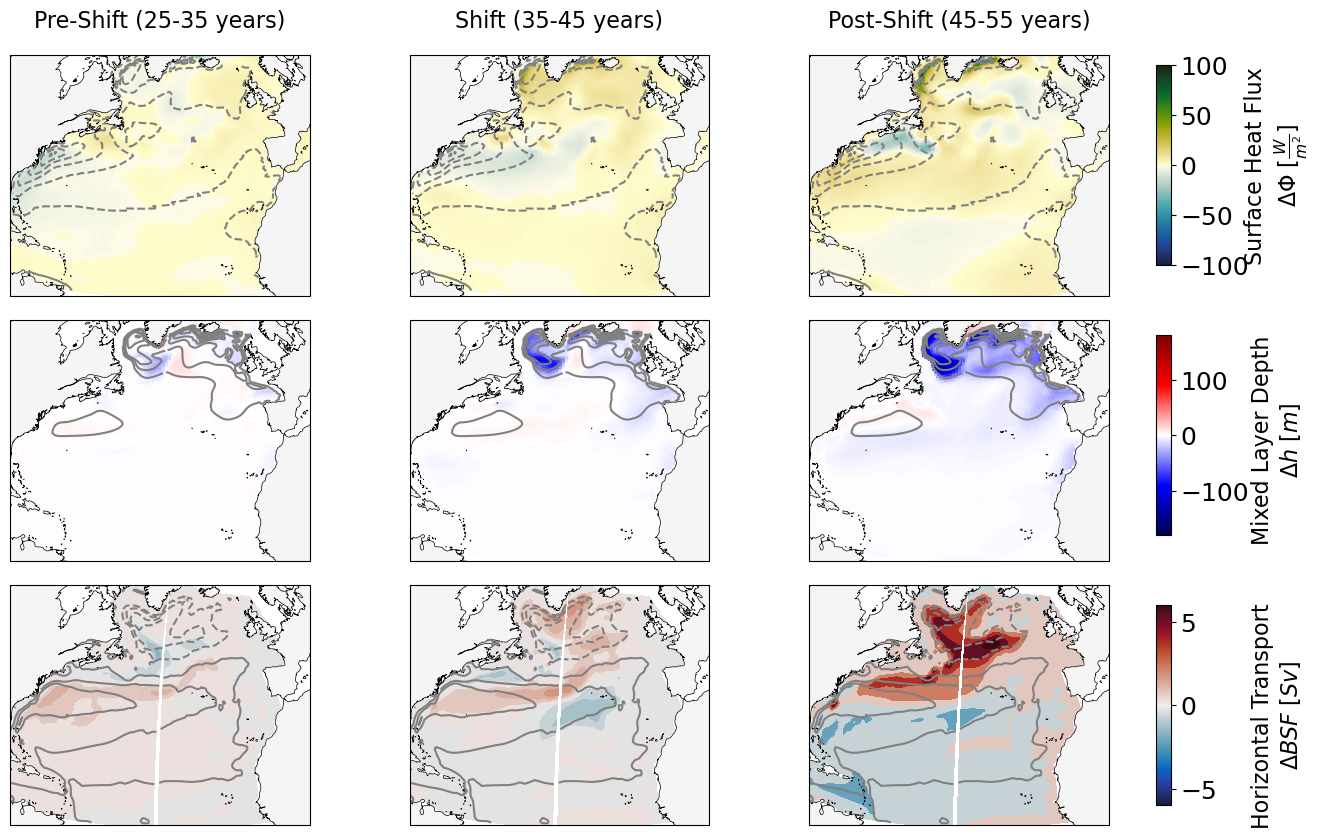

In [47]:
fontsize = 16

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10), 
                         subplot_kw={'projection': ccrs.Orthographic(central_latitude=20, central_longitude=-35)})
plt.rc('font', size=18)

for col, col_name in enumerate(column_names):
    axes[0, col].set_title(col_name, fontsize=20, pad=20)
for row, var in enumerate(variables):
    ds_var_annual = datasets[var]
    if var == 'BSF':
        ds_var_annual['BSF']=ds_var_annual['BSF'] * 1e-12
    ds = ds_var_annual - ds_var_annual.isel(time=slice(0, 40)).mean('time')
    vmin = vmins[row]
    vmax = -vmin
    for col, (start, end) in enumerate(years_ranges):
        ax = axes[row, col]
        if var == 'BSF':
            da = ds.isel(time=slice(start, end)).mean('time')[var]
            contour_fill = ax.contourf(ds_temp.TLONG.where(NA_mask == 1), 
                                        ds_temp.TLAT.where(NA_mask == 1),
                                        da.where(NA_mask == 1),
                                        transform=ccrs.PlateCarree(),
                                        cmap=cmaps[row],
                                        vmin=vmin, vmax=vmax)
            cs = ax.contour(ds_temp.TLONG.where(NA_mask == 1), 
                            ds_temp.TLAT.where(NA_mask == 1),
                            ds_var_annual.isel(time=slice(0, 40)).mean('time')[var].where(NA_mask==1), 
                            linewidths=1.5, colors='grey', transform=ccrs.PlateCarree())
        else:
            da = ds.isel(time=slice(start, end)).mean('time')[var]
            pc = da.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(),
                                    x='TLONG', y='TLAT',
                                    cmap=cmaps[row],vmin=vmin, vmax=vmax,add_colorbar=False)
            cs = ax.contour(ds.TLONG.where(NA_mask==1), ds.TLAT.where(NA_mask==1),
                            ds_var_annual.isel(time=slice(0, 40)).mean('time')[var].where(NA_mask==1), 
                            linewidths=1.5, colors='grey', transform=ccrs.PlateCarree())
        #ax.clabel(cs, fmt='%1.0f', inline=True, fontsize=fontsize)
        ax.set_extent([-75, -5, 10, 65], crs=ccrs.PlateCarree())
        ax.add_feature(nature_coast)   
        ax.set_xlabel('') 
        ax.set_ylabel('') 
cbar_axes = [fig.add_axes([0.91, 0.67 - i * 0.27, 0.01, 0.2]) for i in range(3)]
for row in range(3):
    norm = plt.Normalize(vmin=vmins[row], vmax=-vmins[row])
    sm = plt.cm.ScalarMappable(cmap=cmaps[row], norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_axes[row])
    cbar.ax.set_ylabel('', fontsize=16)
for i, label in enumerate(labels):
    fig.text(0.991, 0.77 - i * 0.275, label, fontsize=fontsize, verticalalignment='center', horizontalalignment='center', rotation=90)
for col, name in enumerate(column_names):
    axes[0, col].set_title(name, fontsize=fontsize, pad=20)
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.savefig(save_name, bbox_inches='tight', dpi=300)
#plt.show()

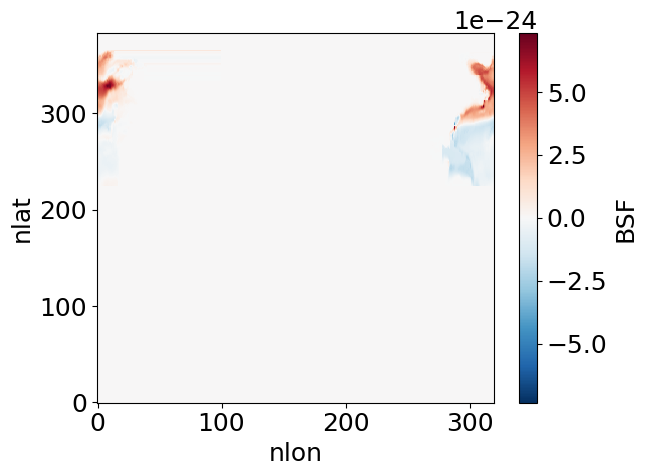

In [41]:
da.plot()